### Práctica 4
Este código nos diseña el controlador PID de la práctica 4 de Control para el motor.

Importemos las librerías a utilizar primero

In [21]:
!pip install control

In [22]:
import control
import numpy as np
import matplotlib.pyplot as plt

Ahora, definamos la función de transferencia de la planta:

In [23]:
num = [780.99]
den = [0.12, 1, 0]
G = control.tf(num, den)
print(G)

<TransferFunction>: sys[19]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      781
  ------------
  0.12 s^2 + s


Ahora, coloquemos las especificaciones de diseño

In [24]:
SP = 5 #5%
zeta = abs(np.log(SP/100)) / np.sqrt(np.log(SP/100)**2 + np.pi**2)
tr = 0.4 #s
wn = (2.23*zeta**2+0.036*zeta+1.54)/tr # rad/s
wn_min = 1/(0.12*(2*zeta+2))
wn_max = 0.25/0.01

print(wn)
print(zeta)
print(SP)
print(tr)
print(wn_min)
print(wn_max)

6.567188300819496
0.6901067305598217
5
0.4
2.465327538981235
25.0


### Control por localización de polos

Hallemos el orden

In [25]:
n = 2 #Grado de la planta
vl = 1
m = 2 #Grado del controlador
q = 2*n - 1 + vl #Grado del polinomio de lazo cerrado

print("Entonces el polinomio de lazo cerrado es de orden:", q)

Entonces el polinomio de lazo cerrado es de orden: 4


Como buscamos PID, necesitamos controlador de la forma
$$
C(s) = \frac{B_2 s^2 + B_1s + B_0}{(A_2s^2 + A_1s + A_0)}
$$

Recuerde que los polos de un sistema de segundo orden están dandos por:

$$
s_{1,2} = -\zeta \omega_n \pm j \, \omega_n \sqrt{1 - \zeta^2}
$$

Esto quiere decir que para este caso, tenemos que:

In [26]:
# theta = np.arccos(zeta)
# tee =  5/zeta*wn
# sigma = 5/tee


# # Rango
# x = np.linspace(-10, 1, 500)

# # Líneas de amortiguamiento
# y_upper = np.tan(theta) * (-x)
# y_lower = -np.tan(theta) * (-x)

# # Figura
# plt.figure(figsize=(8,6))

# # Líneas de ζ
# plt.plot(x, y_upper, 'r--', label='Líneas de ζ')
# plt.plot(x, y_lower, 'r--')

# # Línea de σ
# plt.axvline(x=-sigma, linestyle='--', label='Límite σ')

# # Círculo de wn
# theta_circle = np.linspace(0, 2*np.pi, 500)
# x_circle = wn * np.cos(theta_circle)
# y_circle = wn * np.sin(theta_circle)
# plt.plot(x_circle, y_circle, linestyle='--', label='Círculo ωn')

# # Región de diseño (aproximada)
# x_fill = np.linspace(-wn, -sigma, 500)
# y_fill_upper = np.tan(theta) * (-x_fill)
# y_fill_lower = -np.tan(theta) * (-x_fill)

# # Limitar por el círculo
# y_circle_limit = np.sqrt(np.maximum(0, wn**2 - x_fill**2))

# y_fill_upper = np.minimum(y_fill_upper, y_circle_limit)
# y_fill_lower = np.maximum(y_fill_lower, -y_circle_limit)

# plt.fill_between(x_fill, y_fill_lower, y_fill_upper, alpha=0.3)

# # Ejes
# plt.axhline(0)
# plt.axvline(0)
# plt.xlabel('Parte Real')
# plt.ylabel('Parte Imaginaria')
# plt.title('Región de Diseño en el Plano s')
# plt.legend()
# plt.grid()

# plt.show()

In [27]:
real = -zeta*wn
imag = wn * np.sqrt(1 -  zeta**2)
s1 = real +1j*imag
s2 = real - 1j*imag
print("Polo 1 es: ", s1)
print("Polo 2 es: ", s2)

s3 = real * 1.5
s4 = real * 1.5

print("Polo 1 es " , s3)
print("Polo 2 es: ", s4)

DT = np.poly([s1, s2, s3, s4])
print("Coeficientes de D_T(s):", DT)

Polo 1 es:  (-4.532060847249253+4.7527241299333625j)
Polo 2 es:  (-4.532060847249253-4.7527241299333625j)
Polo 1 es  -6.79809127087388
Polo 2 es:  -6.79809127087388
Coeficientes de D_T(s): [1.00000000e+00 2.26603042e+01 2.12579460e+02 1.00526537e+03
 1.99311758e+03]


### Paso 3: Plantear la ecuación

Con

$$
G(s) = \frac{N(s)}{D(s)} = \frac{781}{0.12s^2 + 1s}
$$

y el controlador

$$
C(s) = \frac{B_2 s^2 + B_1 + B_0}{A_2s^2 + A_1s + A_0}
$$

la condición es:

$$
D_T(s) = A(s)D(s) + B(s)N(s)
$$

$$
(A_2s^2 + A_1s + A_0)(0.16s^2 + s) + (B_2 s^2 + B_1 + B_0)\cdot 781 = s^4 + 25.38s^3 + 237.93s^2 + 1072.3s + 2177
$$

In [28]:
A_mat = np.array([
    [0.12, 0,    0,      0,      0],
    [1,    0.12, 0,      0,      0],
    [0,    1,    781, 0,      0],
    [0,    0,    0,      781, 0],
    [0,    0,    0,      0,      781]
])

b_vec = np.array([
    DT[0],
    DT[1],
    DT[2],
    DT[3],
    DT[4]
])

# Resolver sistema
A2, A1, B2, B1, B0 = np.linalg.solve(A_mat, b_vec)

print(A2, A1, B2, B1, B0)

numC = (1/A2) * np.array([B2, B1, B0])
denC = (1/A2) * np.array([A2, A1, 0])

C = control.tf(numC, denC)
print(C)

8.333333333333336 119.39142419094108 0.11931886818646445 1.2871515667681699 2.55200714690033
<TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.01432 s^2 + 0.1545 s + 0.3062
  -------------------------------
           s^2 + 14.33 s


Finalmente, probemos el sistema en lazo cerrado

Polos del sistema de lazo cerrado [-4.53198024+4.75261108j -4.53198024-4.75261108j -6.79817188+0.01570698j
 -6.79817188-0.01570698j]
DT deseado: [1.00000000e+00 2.26603042e+01 2.12579460e+02 1.00526537e+03
 1.99311758e+03]
Denominador real: [[array([1.20000000e-01, 2.71923651e+00, 2.55093920e+01, 1.20630300e+02,
       2.39171047e+02])]]


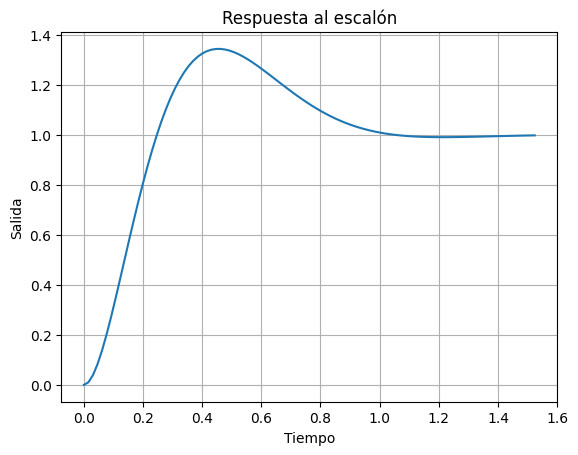

In [29]:
T = control.feedback(C*G,1)
print("Polos del sistema de lazo cerrado", control.poles(T))
print("DT deseado:", DT)
print("Denominador real:", T.den)

t, y = control.step_response(T)
plt.plot(t,y)
plt.grid()
plt.title("Respuesta al escalón")
plt.xlabel("Tiempo")
plt.ylabel("Salida")
plt.show()